### Importing libraries and data

In [490]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

df = pd.read_csv('A:/CODES/PROJECTS/appartments/data/external/gurgaon/properties_cleaned_v3.csv').drop_duplicates()
df.head(2)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,ashiana anmol,sohna road,0.9,9464.0,951.0,Super Built up area 1275(118.45 sq.m.)Carpet a...,2.0,2.0,2,13.0,South,Relatively New,1275.0,NaN,951.0,0.0,0.0,0.0,0.0,0.0,1.0,120.0,475.50
1,flat,tata primanti,sector 72,3.2,12190.0,2625.0,Super Built up area 2625(243.87 sq.m.)Built Up...,4.0,4.0,3+,8.0,North,Moderately Old,2625.0,2600.0,2550.0,0.0,1.0,0.0,0.0,0.0,2.0,168.0,656.25


In [491]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1007
agePossession             0
super_built_up_area    1670
built_up_area          1960
carpet_area            1709
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score            109
area_room_ratio           0
dtype: int64

### Built up area

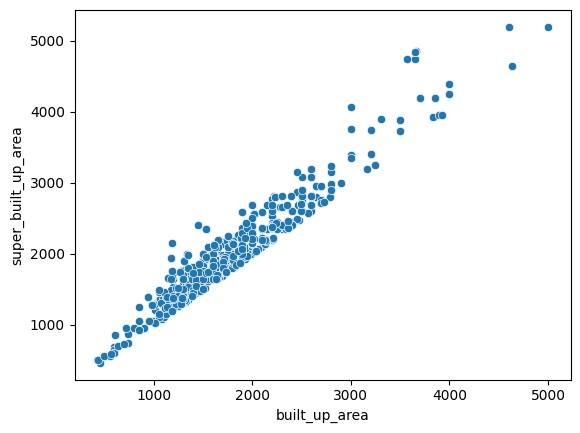

In [492]:
sns.scatterplot(x=df['built_up_area'], y=df['super_built_up_area'])
plt.show()

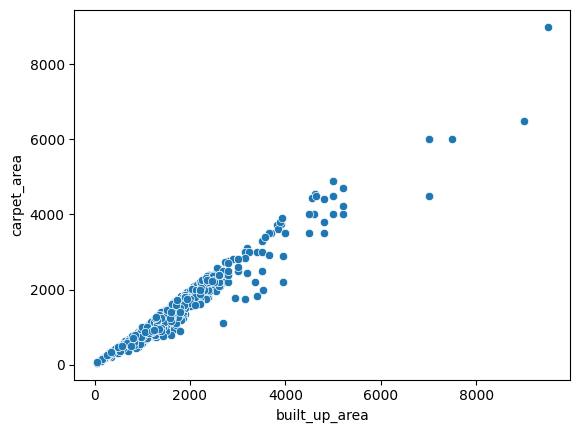

In [493]:
sns.scatterplot(x=df['built_up_area'], y=df['carpet_area'])
plt.show()

In [494]:
# checking if there are any rows where all three area columns are null
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())).sum()

np.int64(0)

In [495]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [496]:
all_present_df.shape

(531, 24)

In [497]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [498]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [499]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [500]:
# both are present but built up area is null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [501]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,ashiana anmol,sohna road,0.90,9464.0,951.0,Super Built up area 1275(118.45 sq.m.)Carpet a...,2.0,2.0,2,13.0,South,Relatively New,1275.0,NaN,951.0,0.0,0.0,0.0,0.0,0.0,1.0,120.0,475.500000
19,flat,ireo victory valley,sector 67,2.95,12236.0,2411.0,Super Built up area 2411(223.99 sq.m.)Carpet a...,3.0,3.0,3,10.0,North-West,Relatively New,2411.0,NaN,1906.0,0.0,1.0,0.0,0.0,0.0,2.0,174.0,803.666667
25,flat,vatika gurgaon,sector 83,1.05,7000.0,1500.0,Super Built up area 1735(161.19 sq.m.)Carpet a...,3.0,3.0,3,3.0,South-West,Relatively New,1735.0,NaN,1500.0,0.0,0.0,1.0,0.0,0.0,0.0,79.0,500.000000
36,flat,shapoorji pallonji joyville gurugram,sector 102,1.20,14563.0,824.0,Super Built up area 1359(126.26 sq.m.)Carpet a...,2.0,2.0,3,0.0,North-East,Relatively New,1359.0,NaN,824.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,412.000000
37,flat,pivotal devaan,sector 84,0.36,7595.0,474.0,Super Built up area 583(54.16 sq.m.)Carpet are...,2.0,2.0,1,9.0,West,Relatively New,583.0,NaN,481.0,0.0,0.0,1.0,0.0,0.0,1.0,80.0,237.000000


In [502]:
# Updating the built up area using the average of the two ratios calculated above
sbc_df.loc[:, 'built_up_area'] = sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2))
df.update(sbc_df)

In [503]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1007
agePossession             0
super_built_up_area    1670
built_up_area          1538
carpet_area            1709
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score            109
area_room_ratio           0
dtype: int64

In [504]:
# super_built_up_area is present, carpet_area and built_up_area area are null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [505]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
3,flat,shree vardhman flora,sector 90,0.90,4615.0,1950.0,Super Built up area 1950(181.16 sq.m.),3.0,4.0,3,4.0,South-West,Relatively New,1950.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,165.0,650.000000
6,flat,tulip violet,sector 69,1.40,8861.0,1580.0,Super Built up area 1578(146.6 sq.m.),3.0,3.0,2,2.0,North-East,Relatively New,1578.0,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,102.0,526.666667
13,flat,godrej aria,sector 79,1.30,9623.0,1351.0,Super Built up area 1351(125.51 sq.m.),2.0,4.0,2,3.0,East,Relatively New,1351.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,53.0,675.500000
14,flat,m3m heights,sector 65,2.44,13297.0,1835.0,Super Built up area 1828(169.83 sq.m.),3.0,3.0,2,7.0,NaN,Under Construction,1828.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,31.0,611.666667
16,flat,sobha city,sector 108,2.10,13972.0,1503.0,Super Built up area 1381(128.3 sq.m.),2.0,2.0,2,3.0,NaN,Under Construction,1381.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,74.0,751.500000


In [506]:
# Updating the built up area by dividing the super built up area by the ratio calculated above
sb_df.loc[:, 'built_up_area'] = sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105))
df.update(sb_df)

In [507]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1007
agePossession             0
super_built_up_area    1670
built_up_area           667
carpet_area            1709
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score            109
area_room_ratio           0
dtype: int64

In [508]:
# carpet_area is present, while super_built_up_area and built_up_area are null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [509]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
4,flat,vatika city,sector 49,3.60,11921.0,3020.0,Carpet area: 3020 (280.57 sq.m.),4.0,5.0,3,7.0,NaN,Moderately Old,NaN,NaN,3020.00000,0.0,1.0,0.0,1.0,0.0,1.0,15.0,755.0
5,flat,tulip white,sector 69,0.91,6863.0,1326.0,Carpet area: 1326 (123.19 sq.m.),3.0,2.0,2,12.0,NaN,Moderately Old,NaN,NaN,1326.00000,0.0,0.0,0.0,0.0,0.0,0.0,43.0,442.0
15,flat,signature global orchard avenue,sector 93,0.40,7353.0,544.0,Carpet area: 543.53 (50.5 sq.m.),2.0,2.0,2,11.0,NaN,New Property,NaN,NaN,543.57695,0.0,0.0,0.0,0.0,0.0,0.0,37.0,272.0
21,house,independent,sector 7,1.16,11694.0,992.0,Plot area 992(92.16 sq.m.)Carpet area: 992 sq....,2.0,4.0,2,3.0,North-East,Moderately Old,NaN,NaN,992.00000,0.0,0.0,0.0,0.0,1.0,0.0,39.0,496.0
28,flat,uphaar residency 2,sector 105,0.42,5600.0,750.0,Carpet area: 750 (69.68 sq.m.),3.0,2.0,1,0.0,East,Moderately Old,NaN,NaN,750.00000,0.0,0.0,0.0,0.0,1.0,0.0,7.0,250.0


In [510]:
# Updating the built up area by dividing the carpet_area by the ratio calculated above
c_df.loc[:, 'built_up_area'] = c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9))
df.update(c_df)

In [511]:
df.isnull().sum()
# Now, all built_up_area are filled

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1007
agePossession             0
super_built_up_area    1670
built_up_area             0
carpet_area            1709
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score            109
area_room_ratio           0
dtype: int64

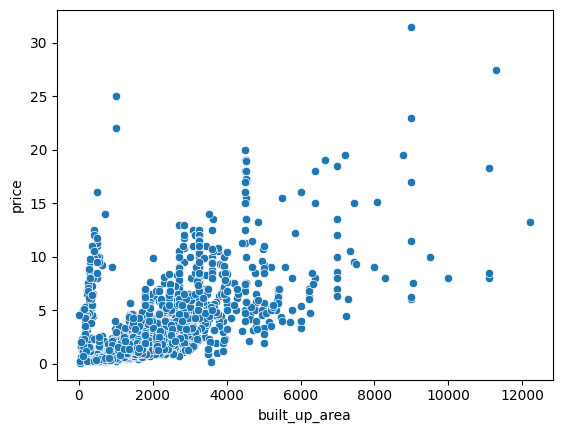

In [512]:
sns.scatterplot(x=df['built_up_area'], y=df['price'])
plt.show()

In [513]:
# anamoly are those rows for which price is more than 2.5 crore but built up area is very less.
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [514]:
anamoly_df.sample(5)

,price,area,built_up_area
3288,2.64,2252.0,1750.75
2009,6.50,2332.0,299.00
316,14.00,6300.0,700.00
3462,3.95,2343.0,1900.00
3451,3.25,1512.0,1512.00


In [515]:
anamoly_df['built_up_area'] = anamoly_df['area']
df.update(anamoly_df)
# updating with area as area is more convincing that built_up_area for high price

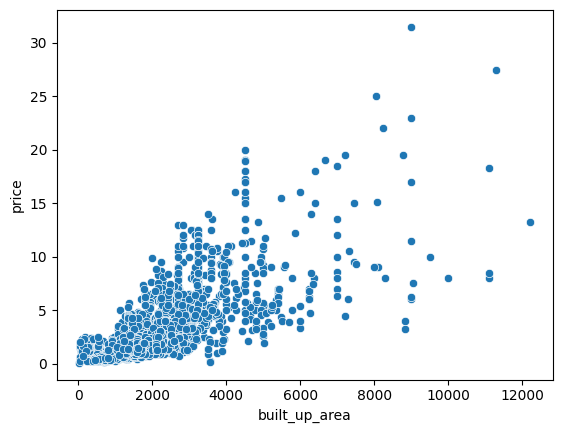

In [516]:
sns.scatterplot(x=df['built_up_area'], y=df['price'])
plt.show()
# Now, those anamolies are gone

In [517]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'], inplace=True)

In [518]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ashiana anmol,sohna road,0.9,9464.0,2.0,2.0,2,13.0,South,Relatively New,1105.0,0.0,0.0,0.0,0.0,0.0,1.0,120.0
1,flat,tata primanti,sector 72,3.2,12190.0,4.0,4.0,3+,8.0,North,Moderately Old,2600.0,0.0,1.0,0.0,0.0,0.0,2.0,168.0
2,house,anamika enclave,sector 12,6.0,14493.0,9.0,9.0,3+,3.0,North-West,Old Property,9000.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0
3,flat,shree vardhman flora,sector 90,0.9,4615.0,3.0,4.0,3,4.0,South-West,Relatively New,1765.0,0.0,1.0,0.0,0.0,0.0,0.0,165.0
4,flat,vatika city,sector 49,3.6,11921.0,4.0,5.0,3,7.0,NaN,Moderately Old,3356.0,0.0,1.0,0.0,1.0,0.0,1.0,15.0


In [519]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1007
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score        109
dtype: int64

### floorNum

In [520]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
292,house,vipul tatvam villa,sector 48,8.50,26235.0,4.0,4.0,1,NaN,NaN,Relatively New,3240.0,0.0,0.0,0.0,0.0,0.0,0.0,42.0
687,flat,experion heartsong,dwarka expressway,1.08,6150.0,3.0,3.0,0,NaN,NaN,Under Construction,1758.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
688,house,ansal sushant lok plots,sector 43,3.30,26570.0,1.0,1.0,0,NaN,NaN,Under Construction,1242.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
851,house,independent,sector 3,1.50,10288.0,3.0,3.0,0,NaN,NaN,Old Property,210.0,0.0,0.0,0.0,0.0,0.0,0.0,159.0
889,house,emaar mgf marbella,sector 66,9.00,21251.0,4.0,4.0,3+,NaN,South-West,Relatively New,5200.0,0.0,1.0,1.0,1.0,0.0,2.0,167.0
1019,house,ansal sushant lok,sector 43,10.50,27911.0,4.0,4.0,2,NaN,North-East,Old Property,3762.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1319,house,independent,sector 4,4.12,8889.0,2.0,1.0,3+,NaN,NaN,Moderately Old,4635.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1665,house,independent,sector 4,0.65,11111.0,4.0,2.0,2,NaN,NaN,Moderately Old,585.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0
2136,flat,NaN,sector 78,0.60,3692.0,2.0,2.0,0,NaN,NaN,Under Construction,1625.0,0.0,0.0,0.0,0.0,0.0,0.0,88.0
2152,house,independent,sector 7,6.50,15046.0,3.0,2.0,3+,NaN,NaN,Old Property,4320.0,0.0,0.0,0.0,0.0,0.0,0.0,174.0


In [521]:
df[df['property_type'] == 'house']['floorNum'].median()
# Simply filling null values with median of floorNum for house property type

np.float64(2.0)

In [522]:
df.loc[:, 'floorNum'] = df['floorNum'].fillna(2.0)

In [523]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1007
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score        109
dtype: int64

In [524]:
1011/df.shape[0]

0.2854319593450028

### facing

In [525]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1007
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score        109
dtype: int64

In [526]:
1007/len(df)
# 28 % or 1/4th of the data is missing in facing, so we will droping this column

0.28430265386787124

<Axes: ylabel='count'>

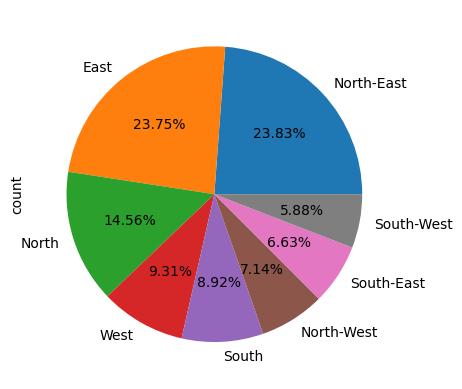

In [527]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [528]:
df.drop(columns=['facing'], inplace=True)

In [529]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3113,flat,m3m skywalk,sector 74,1.78,12500.0,2.0,2.0,3+,12.0,Undefined,1582.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0
463,flat,dlf the ultima,sector 81,2.70,12802.0,3.0,3.0,3,15.0,Relatively New,2343.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0
3411,flat,conscient heritage max,sector 102,1.75,9011.0,3.0,4.0,3+,13.0,Relatively New,1757.0,0.0,1.0,0.0,0.0,0.0,2.0,158.0
1177,flat,dlf new town heights,sector 90,1.21,6244.0,3.0,3.0,3+,7.0,Relatively New,1929.0,0.0,1.0,0.0,1.0,0.0,0.0,60.0
1872,flat,paras dews,sector 106,0.88,6354.0,2.0,2.0,3+,3.0,Relatively New,1120.0,0.0,0.0,0.0,0.0,0.0,0.0,57.0


In [530]:
df.isnull().sum()

property_type        0
society              1
sector               0
price                0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
floorNum             0
agePossession        0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
furnishing_type      0
luxury_score       109
dtype: int64

### society  

In [531]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2136,flat,NaN,sector 78,0.6,3692.0,2.0,2.0,0,2.0,Under Construction,1625.0,0.0,0.0,0.0,0.0,0.0,0.0,88.0


In [532]:
df.drop(index=[2136], inplace=True)
# droping the one row which has null value in society

In [533]:
df.isnull().sum()

property_type        0
society              0
sector               0
price                0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
floorNum             0
agePossession        0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
furnishing_type      0
luxury_score       109
dtype: int64

### agePossession

In [534]:
df.isnull().sum()

property_type        0
society              0
sector               0
price                0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
floorNum             0
agePossession        0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
furnishing_type      0
luxury_score       109
dtype: int64

In [535]:
df['agePossession'].value_counts()
# agePossession has 0 null values, but Undefined can also be considered as null

agePossession
Relatively New        1602
New Property           553
Moderately Old         542
Old Property           291
Undefined              291
Under Construction     262
Name: count, dtype: int64

In [536]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
64,flat,supertech new soft launch,sector 68,0.84,7119.0,2.0,2.0,2,7.0,Undefined,1180.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
79,flat,sare crescent parc,sector 92,0.82,5384.0,3.0,3.0,3+,12.0,Undefined,1523.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
120,house,independent,sector 105,1.35,3857.0,5.0,3.0,3,3.0,Undefined,3500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
121,house,independent,sector 50,7.00,32407.0,3.0,2.0,0,1.0,Undefined,2160.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
125,flat,avl 36 gurgaon,sector 36a,0.50,8333.0,1.0,1.0,1,5.0,Undefined,600.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3474,house,independent,sector 4,0.70,6648.0,3.0,3.0,0,1.0,Undefined,117.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3482,flat,trisara our homes 3,sohna road,0.38,6312.0,2.0,2.0,2,1.0,Undefined,602.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3496,flat,central park flower valley,sector 33,2.50,13270.0,3.0,3.0,2,1.0,Undefined,2093.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3500,flat,godrej air,sector 85,1.40,10000.0,2.0,2.0,3,23.0,Undefined,1400.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [537]:
def mode_based_imputation(row):
    """
        Filling agePossession with mode value of agePossession for the row in the sector and property_type
    """
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [538]:
df['agePossession'] = df.apply(mode_based_imputation, axis=1)

In [539]:
df[df['agePossession'] == 'Undefined'].head(2)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
120,house,independent,sector 105,1.35,3857.0,5.0,3.0,3,3.0,Undefined,3500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
154,house,greenopolis,sector 89,0.70,5397.0,2.0,2.0,2,14.0,Undefined,1297.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [540]:
df['agePossession'].value_counts()

agePossession
Relatively New        1716
New Property           591
Moderately Old         581
Old Property           324
Under Construction     277
Undefined               52
Name: count, dtype: int64

In [ ]:
def mode_based_imputation2(row):
    """
        Filling agePossession with mode value of agePossession for the row in the sector
    """
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [542]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [543]:
df['agePossession'].value_counts()

agePossession
Relatively New        1725
New Property           592
Moderately Old         587
Old Property           327
Under Construction     277
Undefined               33
Name: count, dtype: int64

In [ ]:
def mode_based_imputation3(row):
    """
        Filling agePossession with mode value of agePossession for the row in the property_type
    """
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [545]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [546]:
df['agePossession'].value_counts()

agePossession
Relatively New        1727
Moderately Old         618
New Property           592
Old Property           327
Under Construction     277
Name: count, dtype: int64

### Conclusion

In [547]:
df.isnull().sum()

property_type        0
society              0
sector               0
price                0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
floorNum             0
agePossession        0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
furnishing_type      0
luxury_score       109
dtype: int64

In [550]:
df.shape

(3541, 18)

In [ ]:
df.to_csv('A:/CODES/PROJECTS/appartments/data/external/gurgaon/properties_missing_value_imputation.csv', index=False)